# Simulation Results

Synthetic-signal recovery for the feature-selection methods stored under `results/simulation`.
Compares t-test (signal) against random (null baseline) across signal type, effect size, and top-k.

Sections:
1. Data loading & coverage
2. Recall and FDP summary tables
3. Recall vs effect size
4. FDP vs k
5. Recall heatmaps at k = native
6. Repeat-level recall distribution at effect size = 1.0
7. Block-level metrics (block_recall, block_fdp)


In [46]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "simulation").exists() and (candidate / "src").exists():
            return candidate
    return start


ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.styles.colors import CATEGORICAL, PALETTE

RESULTS_ROOT = ROOT / "results" / "simulation"
FIG_DIR = ROOT / "results" / "figs" / "comparison" / "simulation"
FIG_DIR.mkdir(parents=True, exist_ok=True)

METHODS = ["random", "ttest", "mi", "rf_shap"]
METHOD_LABEL = {"ttest": "t-test", "random": "Random", "mi": "MI", "rf_shap": "RF SHAP"}

recall_frames, fdp_frames, meta_rows = [], [], []

for method in METHODS:
    recall_path = RESULTS_ROOT / method / "recall.parquet"
    fdp_path = RESULTS_ROOT / method / "fdp.parquet"
    meta_path = RESULTS_ROOT / method / "meta.json"

    if not recall_path.exists() or not fdp_path.exists():
        print(f"[WARN] Missing recall/fdp parquet for method='{method}' under {RESULTS_ROOT / method}")
        continue

    r = pd.read_parquet(recall_path).copy(); r["method"] = method; recall_frames.append(r)
    f = pd.read_parquet(fdp_path).copy();    f["method"] = method; fdp_frames.append(f)

    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
        meta_rows.append({
            "method": method,
            "n_repeats": meta.get("n_repeats"),
            "n_features": meta.get("n_features"),
            "signals_per_type": meta.get("signals_per_type"),
            "block_size": meta.get("block_size"),
            "effect_sizes": ", ".join(map(str, meta.get("effect_sizes", []))),
            "topk_values": ", ".join(map(str, meta.get("topk_values", []))),
            "includes_native": meta.get("includes_native"),
            "runtime_seconds": meta.get("runtime_seconds"),
        })

if not recall_frames or not fdp_frames:
    raise FileNotFoundError(f"No simulation result files found under {RESULTS_ROOT}")

recall_df = pd.concat(recall_frames, ignore_index=True)
fdp_df = pd.concat(fdp_frames, ignore_index=True)
recall_df["k"] = recall_df["k"].astype(str)
fdp_df["k"] = fdp_df["k"].astype(str)

if "block_recall" not in recall_df.columns:
    recall_df["block_recall"] = np.nan
if "block_fdp" not in fdp_df.columns:
    fdp_df["block_fdp"] = np.nan
HAS_BLOCK_RECALL = recall_df["block_recall"].notna().any()
HAS_BLOCK_FDP = fdp_df["block_fdp"].notna().any()

k_order = ["10", "25", "50", "100", "native"]
signal_order = ["linear", "bounded_variance", "u_shape", "threshold", "xor_pair"]
SIGNAL_TITLE = {
    "linear": "Linear",
    "bounded_variance": "Bounded variance",
    "threshold": "Threshold",
    "u_shape": "U-shape",
    "xor_pair": "XOR pair",
}

recall_df["k"] = pd.Categorical(recall_df["k"], categories=k_order, ordered=True)
recall_df["signal_type"] = pd.Categorical(recall_df["signal_type"], categories=signal_order, ordered=True)
fdp_df["k"] = pd.Categorical(fdp_df["k"], categories=k_order, ordered=True)

method_order = [m for m in METHODS if m in recall_df["method"].unique()]
recall_df["method"] = pd.Categorical(recall_df["method"], categories=method_order, ordered=True)
fdp_df["method"] = pd.Categorical(fdp_df["method"], categories=method_order, ordered=True)

palette_method = {m: c for m, c in zip(method_order, CATEGORICAL[:len(method_order)])}
palette_k = {k: c for k, c in zip(k_order, CATEGORICAL[:len(k_order)])}

print(f"Project root: {ROOT}")
print(f"Loaded recall rows: {len(recall_df):,} | fdp rows: {len(fdp_df):,}")
print(f"Method order: {method_order}")
print(f"block_recall present: {HAS_BLOCK_RECALL} | block_fdp present: {HAS_BLOCK_FDP}")
pd.DataFrame(meta_rows).set_index("method").reindex(method_order)


Project root: c:\Programmering\exjobb\MSc26_Proteomics
Loaded recall rows: 12,000 | fdp rows: 800
Method order: ['random', 'ttest', 'mi', 'rf_shap']
block_recall present: True | block_fdp present: True


,n_repeats,n_features,signals_per_type,block_size,effect_sizes,topk_values,includes_native,runtime_seconds
method,,,,,,,,
random,50,11000,3,20,"0.3, 0.6, 1.0","10, 25, 50, 100",True,123.760381
ttest,50,11000,3,20,"0.3, 0.6, 1.0","10, 25, 50, 100",True,119.827227
mi,10,11000,3,20,"0.3, 0.6, 1.0","10, 25, 50, 100",True,29853.815371
rf_shap,50,11000,3,20,"0.3, 0.6, 1.0","10, 25, 50, 100",True,3311.342677


## 1. Coverage check

In [47]:
recall_coverage = (
    recall_df.groupby("method", observed=False)
    .agg(n_rows=("repeat", "size"),
         repeats=("repeat", "nunique"),
         signal_types=("signal_type", "nunique"),
         effect_sizes=("effect_size", "nunique"),
         k_values=("k", "nunique"))
    .sort_index()
)
fdp_coverage = (
    fdp_df.groupby("method", observed=False)
    .agg(n_rows=("repeat", "size"),
         repeats=("repeat", "nunique"),
         k_values=("k", "nunique"))
    .sort_index()
)
print("Recall coverage"); display(recall_coverage)
print("FDP coverage");    display(fdp_coverage)


Recall coverage


,n_rows,repeats,signal_types,effect_sizes,k_values
method,,,,,
random,3750,50,5,3,5
ttest,3750,50,5,3,5
mi,750,10,5,3,5
rf_shap,3750,50,5,3,5


FDP coverage


,n_rows,repeats,k_values
method,,,
random,250,50,5
ttest,250,50,5
mi,50,10,5
rf_shap,250,50,5


## 2. Recall and FDP summary tables

In [48]:
recall_summary_method_k = (
    recall_df.groupby(["method", "k"], observed=False)
    .agg(recall_mean=("recall", "mean"),
         recall_std=("recall", "std"))
    .reset_index().round(3)
)

fdp_summary_method_k = (
    fdp_df.groupby(["method", "k"], observed=False)
    .agg(fdp_mean=("fdp", "mean"),
         fdp_std=("fdp", "std"),
         n_selected_mean=("n_selected", "mean"))
    .reset_index().round(3)
)

print("Mean recall by method x k")
display(
    recall_summary_method_k
    .pivot(index="k", columns="method", values="recall_mean")
    .reindex(k_order)
    .style.background_gradient(cmap="YlGnBu", vmin=0, vmax=1)
    .format("{:.3f}")
    .set_caption("Mean recall")
)

print("Mean FDP by method x k")
display(
    fdp_summary_method_k
    .pivot(index="k", columns="method", values="fdp_mean")
    .reindex(k_order)
    .style.background_gradient(cmap="YlOrRd", vmin=0, vmax=1)
    .format("{:.3f}")
    .set_caption("Mean FDP")
)


Mean recall by method x k


method,random,ttest,mi,rf_shap
k,,,,
10,0.002,0.138,0.129,0.187
25,0.003,0.163,0.176,0.268
50,0.006,0.179,0.197,0.307
100,0.010,0.201,0.243,0.344
native,0.003,0.109,0.053,0.000


Mean FDP by method x k


method,random,ttest,mi,rf_shap
k,,,,
10,0.992,0.376,0.420,0.160
25,0.994,0.705,0.684,0.518
50,0.993,0.838,0.822,0.724
100,0.994,0.909,0.890,0.845
native,0.992,0.047,0.063,nan


## 3. Recall vs effect size

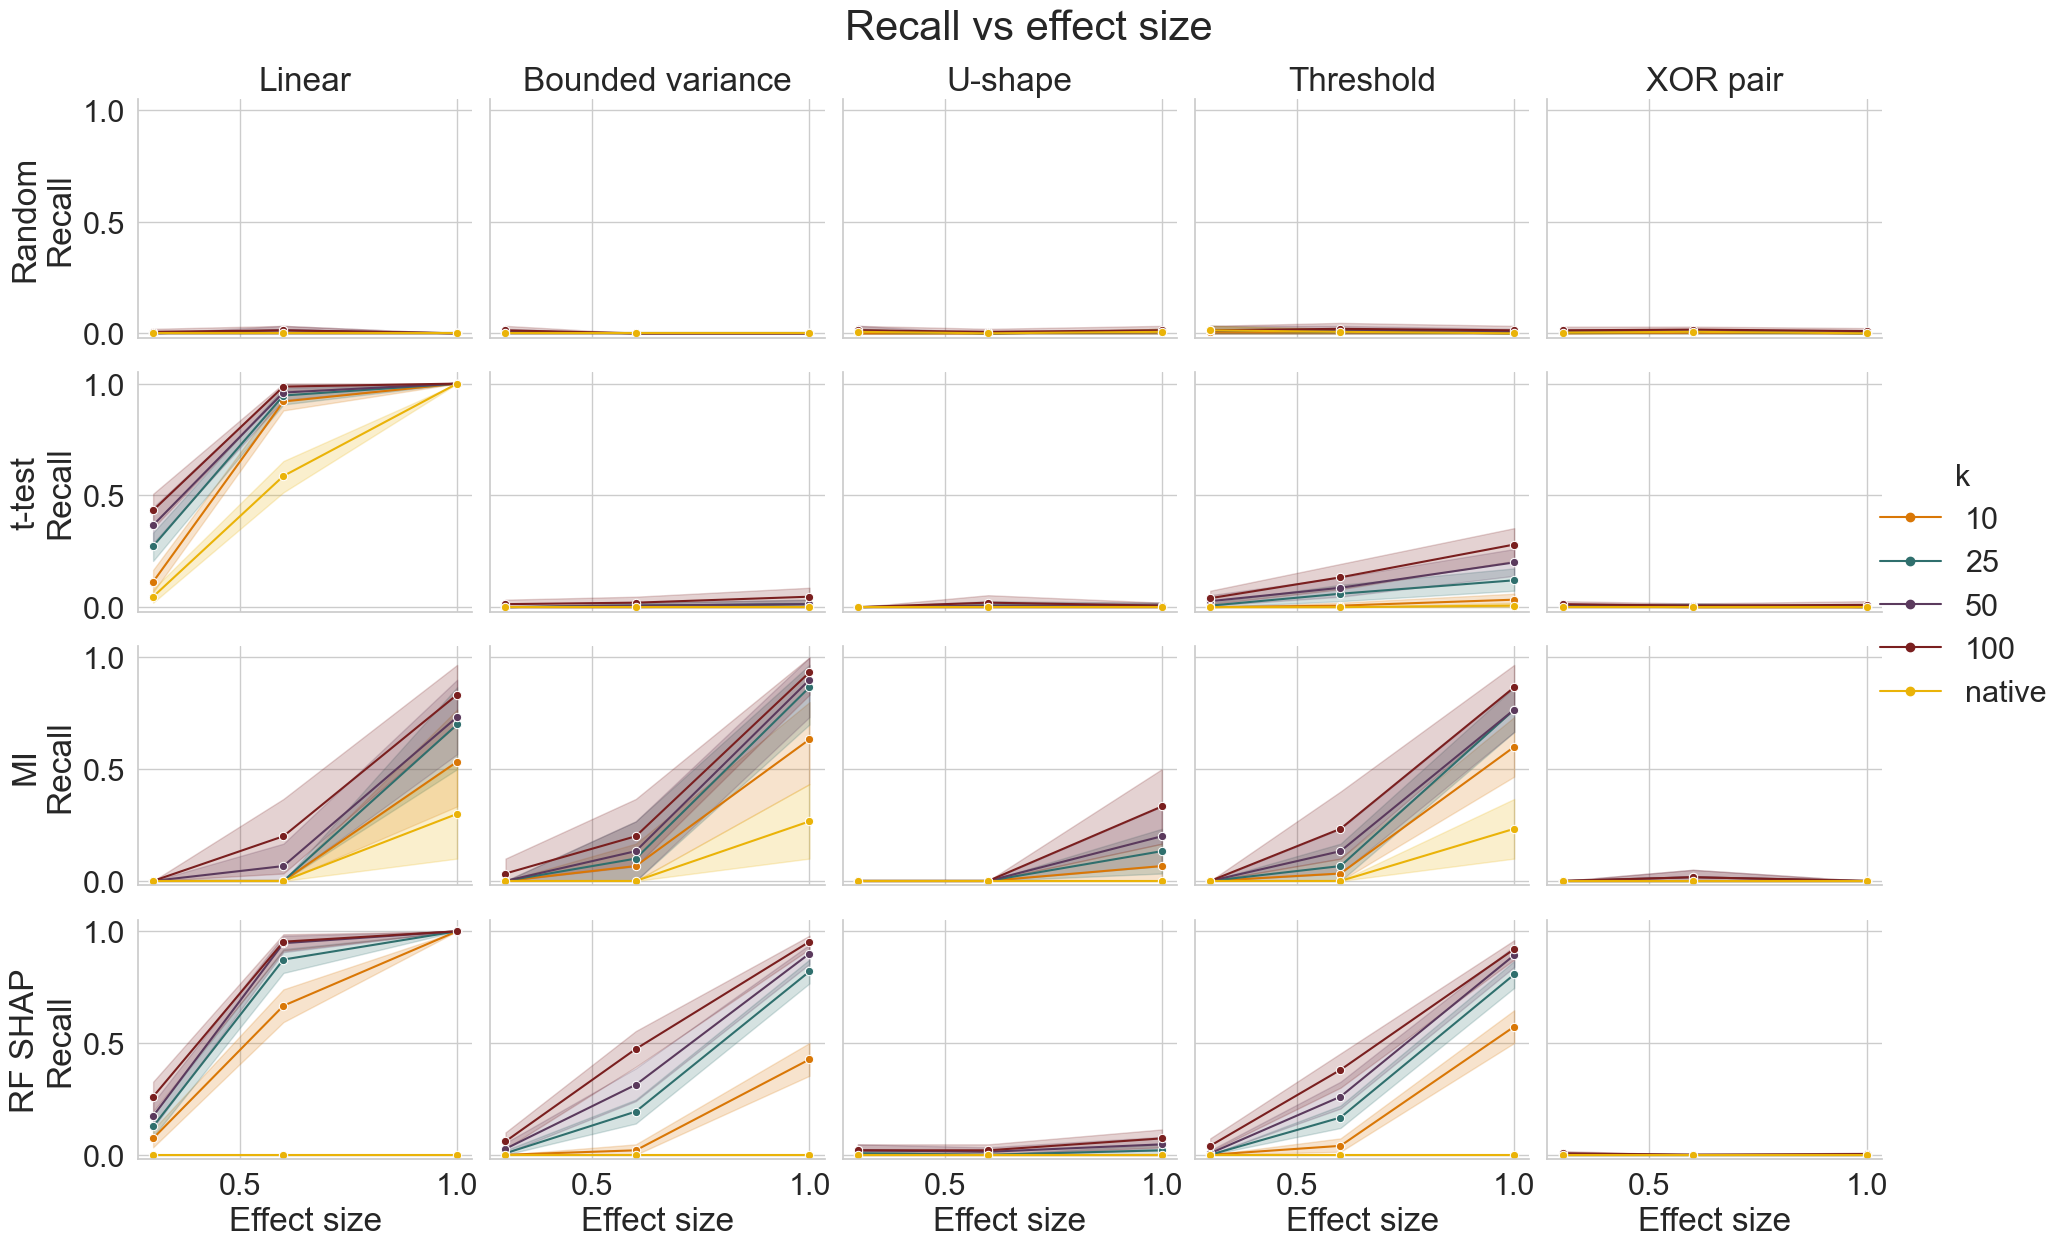

In [51]:
FONTSIZE_TITLE   = 30
FONTSIZE_SUBPLOT = 24
FONTSIZE_LABEL   = 24
FONTSIZE_TICK    = 22
FONTSIZE_LEGEND  = 22

plot_signal_order = [s for s in signal_order if s in recall_df["signal_type"].unique()]

g = sns.relplot(
    data=recall_df, kind="line",
    x="effect_size", y="recall",
    hue="k", hue_order=k_order, palette=palette_k,
    col="signal_type", col_order=plot_signal_order,
    row="method", row_order=method_order,
    marker="o", errorbar=("ci", 95),
    height=3.2, aspect=1.15,
    facet_kws={"sharey": True},
)
g.set_axis_labels("Effect size", "Recall", fontsize=FONTSIZE_LABEL)
g.set(ylim=(-0.02, 1.05))

for ax in g.axes.flat:
    ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j, sig in enumerate(plot_signal_order):
    g.axes[0, j].set_title(SIGNAL_TITLE.get(sig, sig), fontsize=FONTSIZE_SUBPLOT)
for i in range(1, g.axes.shape[0]):
    for ax in g.axes[i]:
        ax.set_title("")
for i, m in enumerate(method_order):
    g.axes[i, 0].set_ylabel(f"{METHOD_LABEL[m]}\nRecall", fontsize=FONTSIZE_LABEL)

g._legend.get_title().set_fontsize(FONTSIZE_LEGEND)
g._legend.get_title().set_text("k")
for t in g._legend.get_texts():
    t.set_fontsize(FONTSIZE_LEGEND)
sns.move_legend(g, loc="center right", bbox_to_anchor=(1.04, 0.5), fontsize=FONTSIZE_LEGEND)

g.fig.suptitle("Recall vs effect size", y=0.95, fontsize=FONTSIZE_TITLE)
g.fig.subplots_adjust(top=0.88)
g.fig.savefig(FIG_DIR / "recall_vs_effect.pdf", bbox_inches="tight", dpi=300)
plt.show()


## 4. FDP vs k

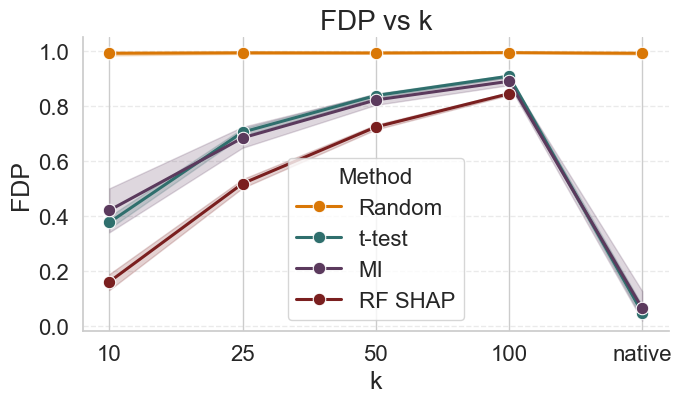

In [56]:
FONTSIZE_TITLE = 20
FONTSIZE_LABEL = 18
FONTSIZE_TICK  = 16
FONTSIZE_LEGEND = 16

INCLUDE_NATIVE = True  # toggle to include/exclude k="native"

k_order_plot = k_order if INCLUDE_NATIVE else [k for k in k_order if k != "native"]
fdp_plot_df = fdp_df[fdp_df["k"].isin(k_order_plot)].copy()
fdp_plot_df["k"] = pd.Categorical(fdp_plot_df["k"], categories=k_order_plot, ordered=True)

fig, ax = plt.subplots(figsize=(7, 4.2))
sns.lineplot(
    data=fdp_plot_df, x="k", y="fdp", hue="method", hue_order=method_order,
    palette=palette_method, marker="o", errorbar=("ci", 95),
    linewidth=2.2, markersize=9, ax=ax,
)
ax.set_xlabel("k", fontsize=FONTSIZE_LABEL)
ax.set_ylabel("FDP", fontsize=FONTSIZE_LABEL)
ax.set_title("FDP vs k", fontsize=FONTSIZE_TITLE)
ax.set_ylim(-0.02, 1.05)
ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [METHOD_LABEL.get(l, l) for l in labels],
          title="Method", fontsize=FONTSIZE_LEGEND, title_fontsize=FONTSIZE_LEGEND,
          frameon=True, loc="best")

fig.tight_layout()
suffix = "_with_native" if INCLUDE_NATIVE else "_no_native"
fig.savefig(FIG_DIR / f"fdp_vs_k{suffix}.pdf", bbox_inches="tight", dpi=300)
plt.show()


## 5. Recall heatmap at k

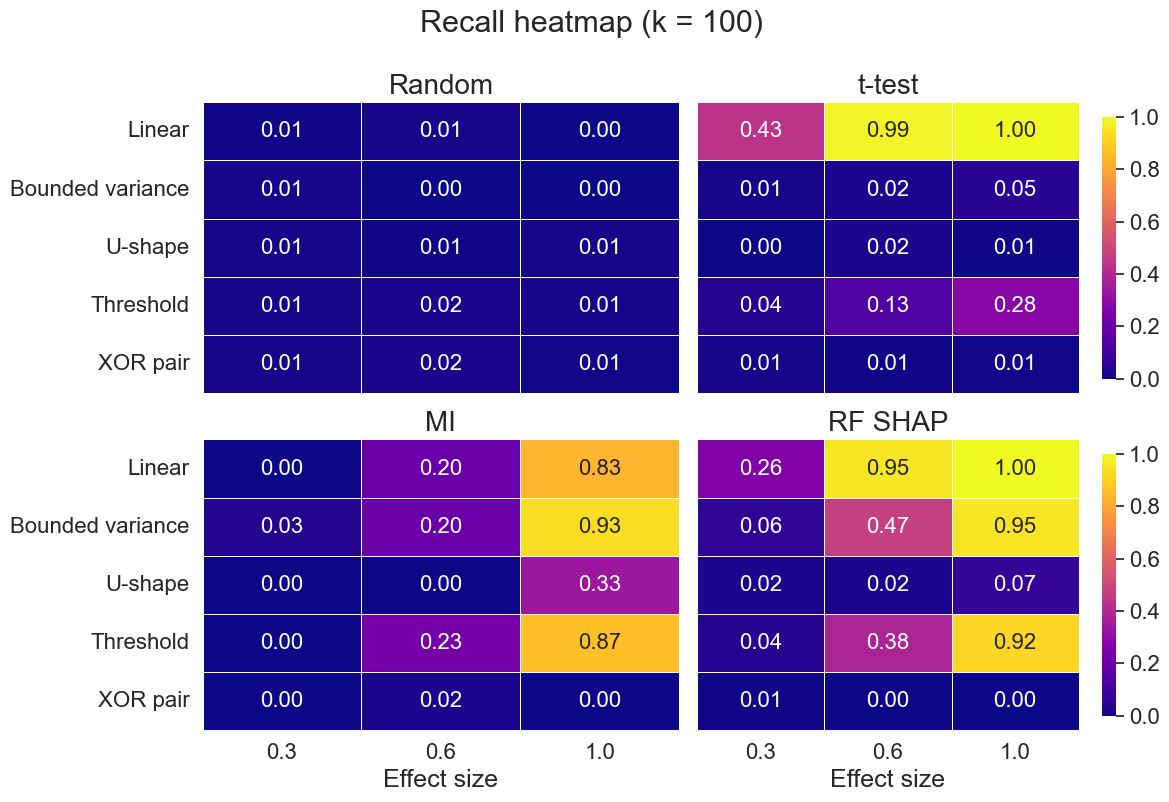

In [60]:
FONTSIZE_TITLE  = 20
FONTSIZE_LABEL  = 18
FONTSIZE_TICK   = 16
FONTSIZE_ANNOT  = 16

k_focus = "100"
native_df = (
    recall_df[recall_df["k"] == k_focus]
    .groupby(["method", "signal_type", "effect_size"], observed=False)
    .agg(recall_mean=("recall", "mean"))
    .reset_index()
)

n_methods = len(method_order)
n_cols = 2
n_rows = int(np.ceil(n_methods / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6.0 * n_cols, 4.0 * n_rows),
    sharey=True, sharex=True,
)
axes = np.atleast_2d(axes)

cmap = sns.color_palette("plasma", as_cmap=True)

for idx, method in enumerate(method_order):
    r, c = divmod(idx, n_cols)
    ax = axes[r, c]
    matrix = (
        native_df[native_df["method"] == method]
        .pivot(index="signal_type", columns="effect_size", values="recall_mean")
        .reindex([s for s in signal_order if s in native_df["signal_type"].unique()])
    )
    matrix.index = [SIGNAL_TITLE.get(s, s) for s in matrix.index]
    is_right_col = (c == n_cols - 1)
    sns.heatmap(
        matrix, annot=True, fmt=".2f",
        cmap=cmap, vmin=0.0, vmax=1.0,
        cbar=is_right_col,
        annot_kws={"size": FONTSIZE_ANNOT},
        linewidths=0.5, linecolor="white", ax=ax,
        cbar_kws={"shrink": 0.9},
    )
    ax.set_title(METHOD_LABEL[method], fontsize=FONTSIZE_TITLE)
    ax.set_xlabel("Effect size" if r == n_rows - 1 else "", fontsize=FONTSIZE_LABEL)
    #ax.set_ylabel("Signal type" if c == 0 else "", fontsize=FONTSIZE_LABEL)
    ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)
    if is_right_col:
        ax.collections[0].colorbar.ax.tick_params(labelsize=FONTSIZE_TICK)

# Hide unused axes if n_methods doesn't fill the grid
for idx in range(n_methods, n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    axes[r, c].set_visible(False)

fig.suptitle(f"Recall heatmap (k = {k_focus})", fontsize=FONTSIZE_TITLE + 2, y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / f"recall_heatmap_k_{k_focus}_grid.pdf", bbox_inches="tight", dpi=300)
plt.show()


## 6. Block-level metrics

`block_recall` counts a planted feature as found if **any feature in its block** is selected (pathway-discovery framing). `block_fdp` counts a selected feature as a false discovery only if its block contains **no** planted signal. Both metrics fall back to strict versions when `block_size=None`.

In [43]:
if HAS_BLOCK_RECALL:
    block_recall_summary = (
        recall_df.groupby(["method", "k"], observed=False)
        .agg(recall_mean=("recall", "mean"),
             block_recall_mean=("block_recall", "mean"),
             block_recall_std=("block_recall", "std"))
        .assign(gap=lambda d: (d["block_recall_mean"] - d["recall_mean"]).round(3))
        .reset_index().round(3)
    )
    display(
        block_recall_summary
        .pivot(index="k", columns="method", values="block_recall_mean")
        .reindex(k_order)
        .style.background_gradient(cmap="YlGnBu", vmin=0, vmax=1)
        .format("{:.3f}")
        .set_caption("Mean block recall")
    )
else:
    print("block_recall not present - re-run scripts/05_run_simulation.py to populate.")

if HAS_BLOCK_FDP:
    block_fdp_summary = (
        fdp_df.groupby(["method", "k"], observed=False)
        .agg(fdp_mean=("fdp", "mean"),
             block_fdp_mean=("block_fdp", "mean"),
             block_fdp_std=("block_fdp", "std"),
             n_selected_mean=("n_selected", "mean"))
        .assign(gap=lambda d: (d["fdp_mean"] - d["block_fdp_mean"]).round(3))
        .reset_index().round(3)
    )
    display(
        block_fdp_summary
        .pivot(index="k", columns="method", values="block_fdp_mean")
        .reindex(k_order)
        .style.background_gradient(cmap="YlOrRd", vmin=0, vmax=1)
        .format("{:.3f}")
        .set_caption("Mean block FDP")
    )
else:
    print("block_fdp not present - re-run scripts/05_run_simulation.py to populate.")


method,random,ttest,mi,rf_shap
k,,,,
10,0.015,0.151,0.142,0.203
25,0.044,0.186,0.212,0.299
50,0.088,0.218,0.263,0.356
100,0.167,0.270,0.372,0.426
native,0.033,0.118,0.056,0.000


method,random,ttest,mi,rf_shap
k,,,,
10,0.924,0.346,0.400,0.144
25,0.910,0.647,0.632,0.477
50,0.906,0.769,0.756,0.667
100,0.906,0.832,0.814,0.774
native,0.914,0.041,0.063,nan


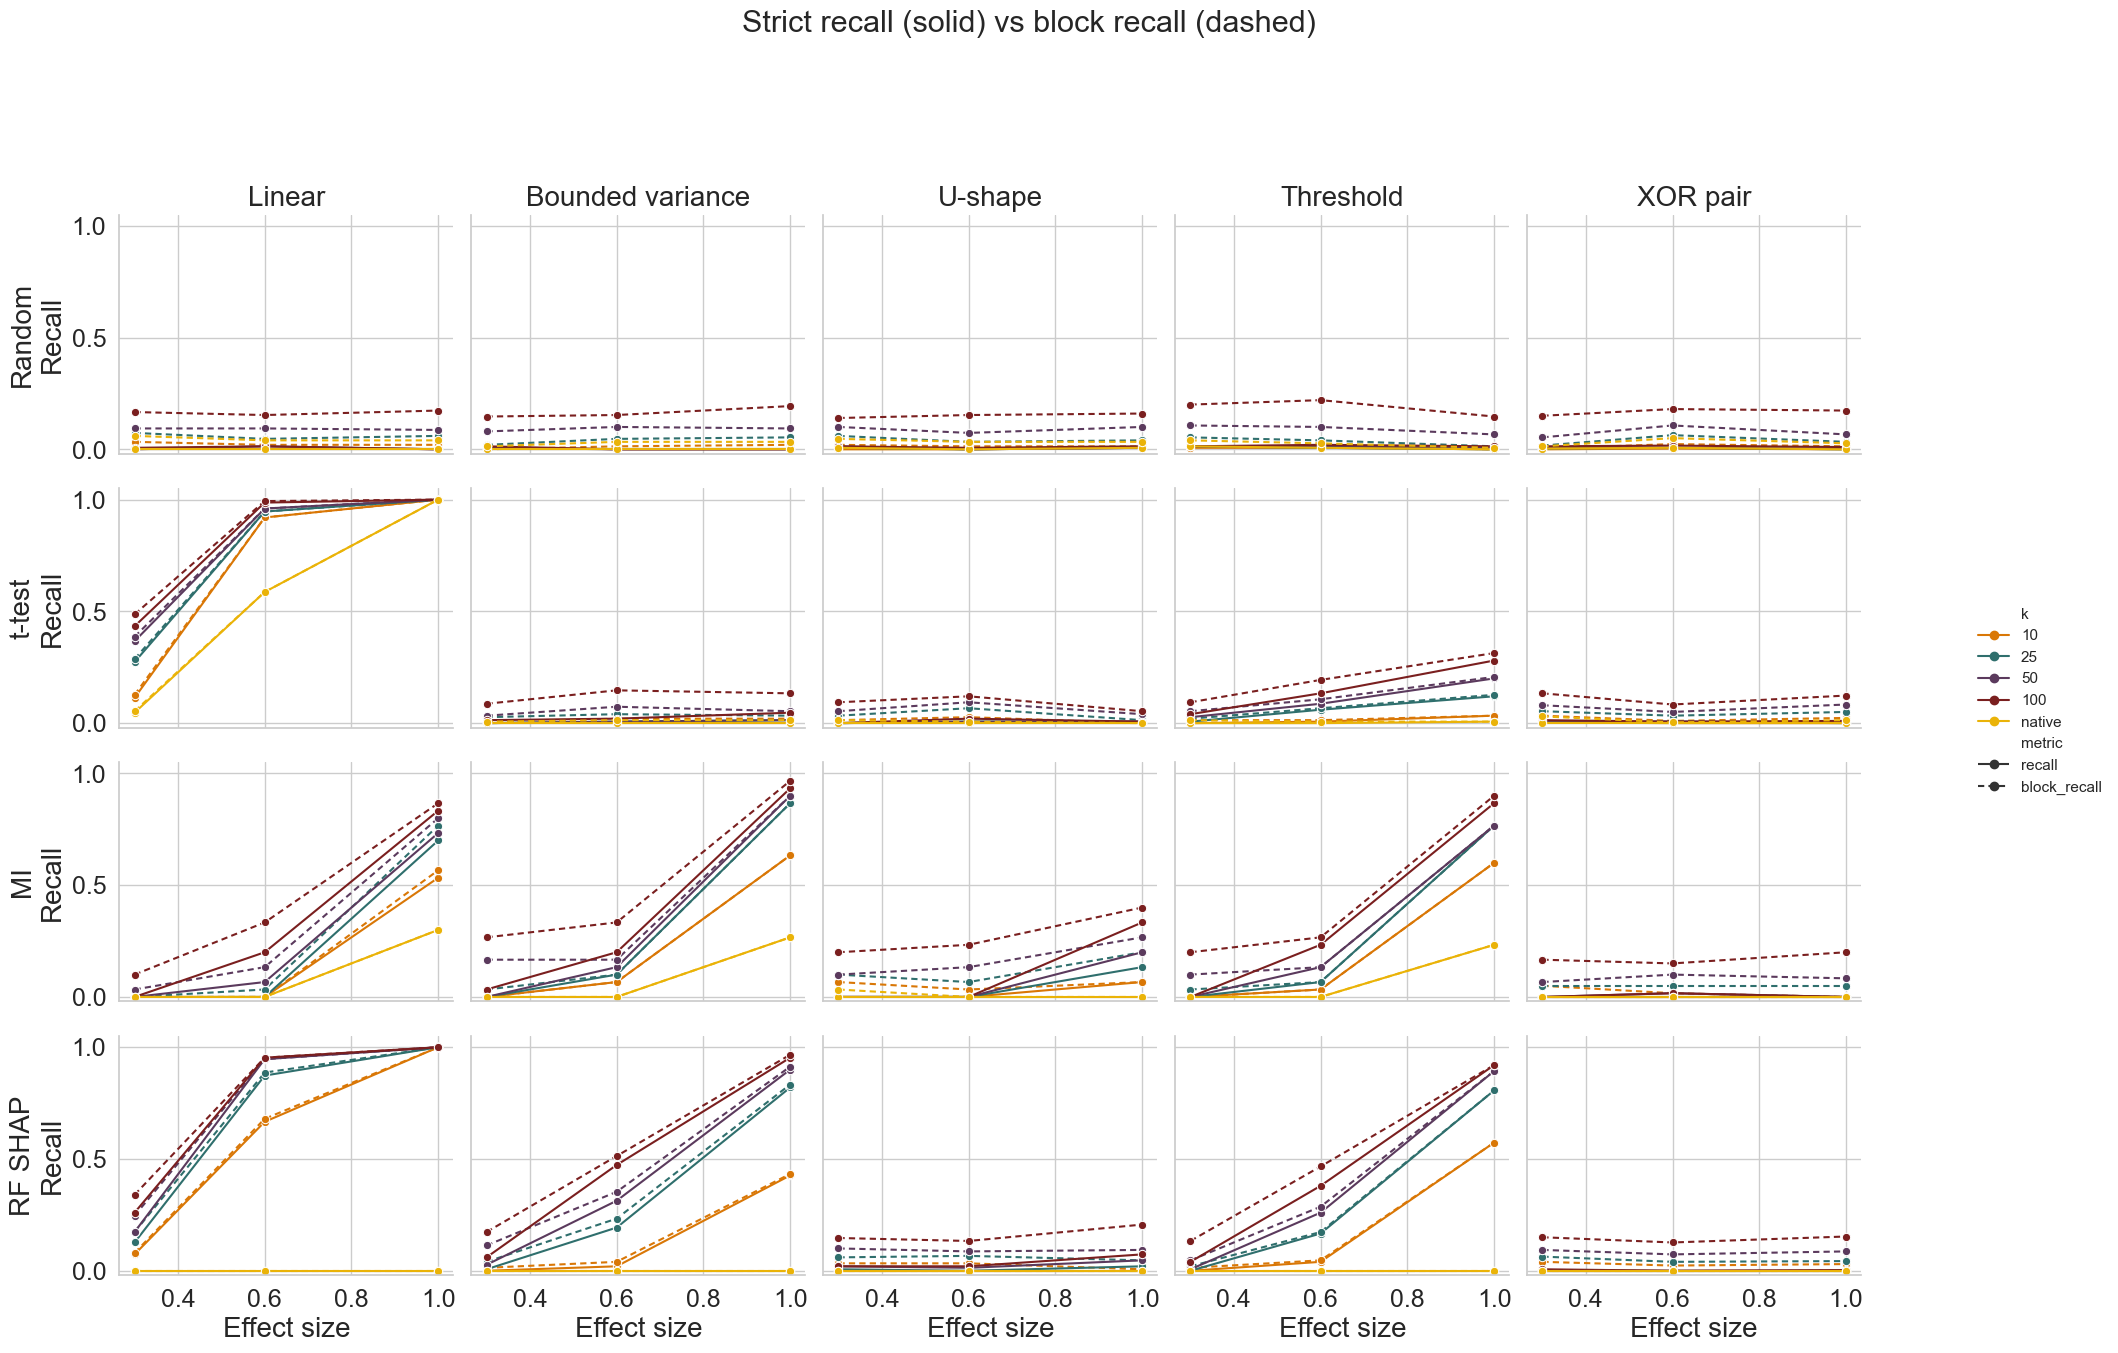

In [44]:
FONTSIZE_TITLE = 22
FONTSIZE_SUBPLOT = 20
FONTSIZE_LABEL = 20
FONTSIZE_TICK  = 18
FONTSIZE_LEGEND = 18

if HAS_BLOCK_RECALL:
    long_recall = (
        recall_df.melt(
            id_vars=["method", "signal_type", "effect_size", "k"],
            value_vars=["recall", "block_recall"],
            var_name="metric", value_name="value",
        )
        .groupby(["method", "signal_type", "effect_size", "k", "metric"], observed=False)
        .agg(value_mean=("value", "mean")).reset_index()
    )

    plot_signal_order = [s for s in signal_order if s in long_recall["signal_type"].unique()]
    g = sns.relplot(
        data=long_recall, kind="line",
        x="effect_size", y="value_mean",
        hue="k", hue_order=k_order, palette=palette_k,
        style="metric", style_order=["recall", "block_recall"],
        dashes={"recall": (1, 0), "block_recall": (3, 2)},
        col="signal_type", col_order=plot_signal_order,
        row="method", row_order=method_order,
        marker="o", height=3.2, aspect=1.15,
    )
    g.set_axis_labels("Effect size", "Mean recall", fontsize=FONTSIZE_LABEL)
    g.set(ylim=(-0.02, 1.05))

    for ax in g.axes.flat:
        ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j, sig in enumerate(plot_signal_order):
        g.axes[0, j].set_title(SIGNAL_TITLE.get(sig, sig), fontsize=FONTSIZE_SUBPLOT)
    for i in range(1, g.axes.shape[0]):
        for ax in g.axes[i]:
            ax.set_title("")
    for i, m in enumerate(method_order):
        g.axes[i, 0].set_ylabel(f"{METHOD_LABEL[m]}\nRecall", fontsize=FONTSIZE_LABEL)

    g._legend.get_title().set_fontsize(FONTSIZE_LEGEND)
    for t in g._legend.get_texts():
        t.set_fontsize(FONTSIZE_LEGEND)
    sns.move_legend(g, loc="center right", bbox_to_anchor=(1.05, 0.5))

    g.fig.suptitle("Strict recall (solid) vs block recall (dashed)", y=1.04, fontsize=FONTSIZE_TITLE)
    g.fig.subplots_adjust(top=0.88)
    g.fig.savefig(FIG_DIR / "recall_vs_block_recall.pdf", bbox_inches="tight", dpi=300)
    plt.show()
else:
    print("Skipping recall vs block_recall plot: block_recall not populated.")


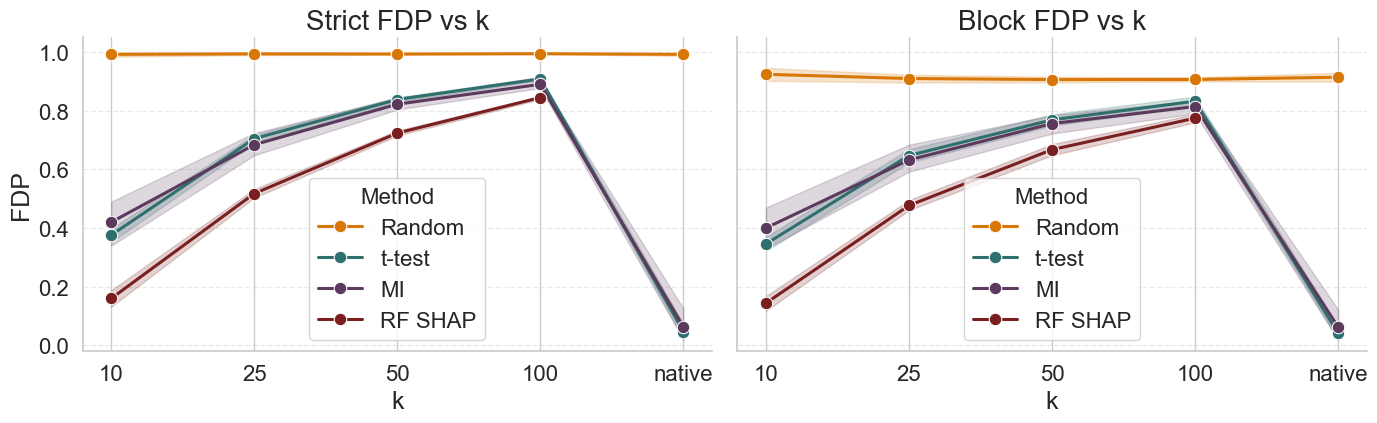

In [45]:
FONTSIZE_TITLE = 20
FONTSIZE_LABEL = 18
FONTSIZE_TICK  = 16
FONTSIZE_LEGEND = 16

if HAS_BLOCK_FDP:
    long_fdp = fdp_df.melt(
        id_vars=["method", "k"],
        value_vars=["fdp", "block_fdp"],
        var_name="metric", value_name="value",
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
    for ax, metric, title in [
        (axes[0], "fdp",       "Strict FDP vs k"),
        (axes[1], "block_fdp", "Block FDP vs k"),
    ]:
        sns.lineplot(
            data=long_fdp[long_fdp["metric"] == metric],
            x="k", y="value", hue="method", hue_order=method_order,
            palette=palette_method, marker="o", errorbar=("ci", 95),
            linewidth=2.2, markersize=9, ax=ax,
        )
        ax.set_title(title, fontsize=FONTSIZE_TITLE)
        ax.set_xlabel("k", fontsize=FONTSIZE_LABEL)
        ax.set_ylabel("FDP" if ax is axes[0] else "", fontsize=FONTSIZE_LABEL)
        ax.set_ylim(-0.02, 1.05)
        ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        h, l = ax.get_legend_handles_labels()
        ax.legend(h, [METHOD_LABEL.get(x, x) for x in l],
                  title="Method", fontsize=FONTSIZE_LEGEND,
                  title_fontsize=FONTSIZE_LEGEND, frameon=True, loc="best")

    fig.tight_layout()
    fig.savefig(FIG_DIR / "fdp_vs_block_fdp.pdf", bbox_inches="tight", dpi=300)
    plt.show()
else:
    print("Skipping FDP vs block_fdp plot: block_fdp not populated.")
